# Рис. 210 и Рис. 211 (иллюстрация сумм Римана)

Ниже — две ячейки с кодом, которые строят графики, похожие на картинку:  
- **Рис. 210**: возрастающая кривая и прямоугольники по разбиению \([a,b]\) (правые/левые значения можно менять).  
- **Рис. 211**: кривая и прямоугольники с разными высотами (часть заштрихована для визуального акцента).

Можно менять функцию `f(x)`, точки разбиения и выбор точки в каждом интервале.


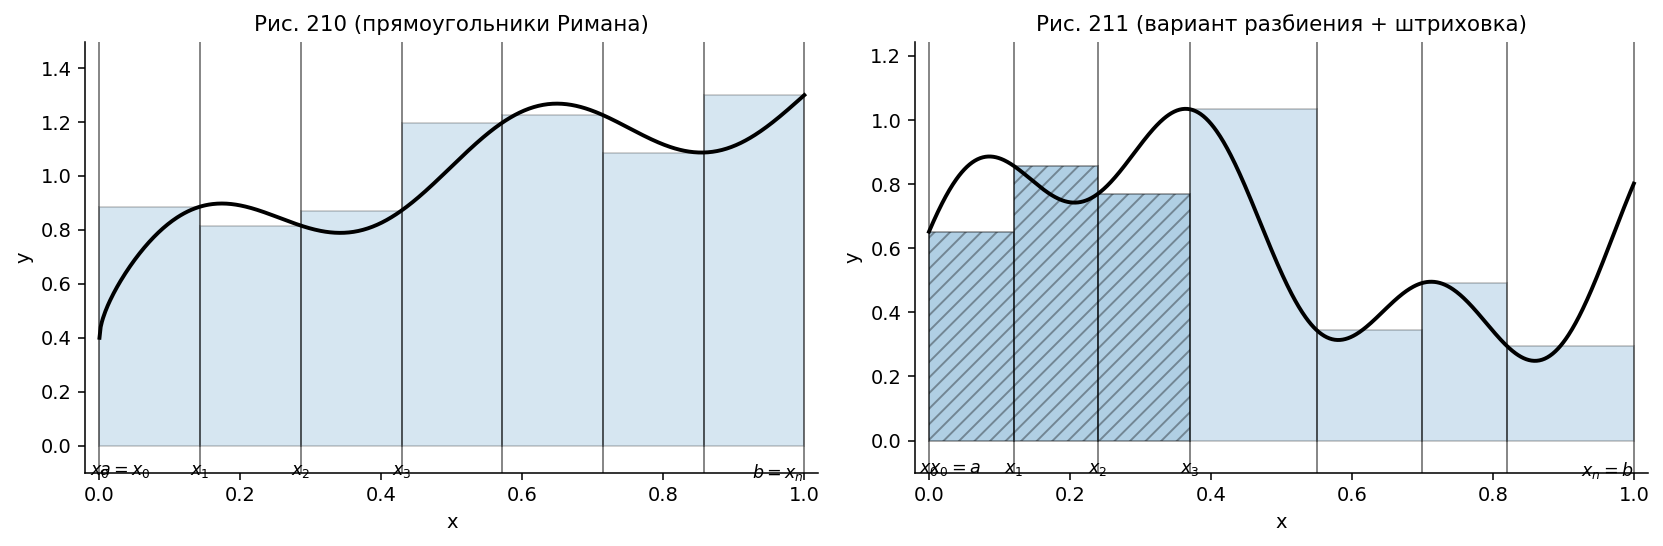

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ---------- Настройки ----------
def f(x):
    # Можно заменить на любую гладкую функцию
    return 0.4 + 0.9*np.sqrt(x) + 0.15*np.sin(4*np.pi*x)

a, b = 0.0, 1.0

# Разбиение для Рис. 210 (n интервалов)
n = 7
xs = np.linspace(a, b, n+1)

# Разбиение для Рис. 211 (неравномерное, как на картинке)
xs2 = np.array([0.0, 0.12, 0.24, 0.37, 0.55, 0.70, 0.82, 1.0])

# Выбор точки в каждом интервале: 'left', 'right', 'mid'
sample_mode_210 = 'right'
sample_mode_211 = 'left'

# ---------- Вспомогательные функции ----------
def sample_points(x_edges, mode='right'):
    x_edges = np.asarray(x_edges)
    if mode == 'left':
        return x_edges[:-1]
    if mode == 'right':
        return x_edges[1:]
    if mode == 'mid':
        return 0.5*(x_edges[:-1] + x_edges[1:])
    raise ValueError('mode must be left/right/mid')

def draw_riemann_rectangles(ax, x_edges, mode='right', hatch_every=None, facealpha=0.25):
    """Рисует прямоугольники Римана. hatch_every=[idxs] — какие интервалы штриховать."""
    x_edges = np.asarray(x_edges)
    x_s = sample_points(x_edges, mode)
    heights = f(x_s)

    for i in range(len(x_edges)-1):
        x0, x1 = x_edges[i], x_edges[i+1]
        w = x1 - x0
        h = heights[i]
        rect = Rectangle((x0, 0), w, h,
                         facecolor='C0', edgecolor='k', linewidth=1,
                         alpha=facealpha)
        if hatch_every is not None and i in hatch_every:
            rect.set_hatch('///')
            rect.set_alpha(0.35)
        ax.add_patch(rect)

    return x_s, heights

# ---------- Построение ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=140)

# ===== Рис. 210 =====
ax = axes[0]
x = np.linspace(a, b, 600)
ax.plot(x, f(x), color='k', linewidth=2)

# Прямоугольники
x_s, heights = draw_riemann_rectangles(ax, xs, mode=sample_mode_210, facealpha=0.18)

# Вертикальные линии разбиения
for xv in xs:
    ax.axvline(xv, color='k', linewidth=0.8, alpha=0.6)

# Подписи ключевых точек (похоже на схему)
for i, xv in enumerate(xs[:4]):  # несколько первых, чтобы не загромождать
    ax.text(xv, -0.06, fr'$x_{i}$', ha='center', va='top', fontsize=9)
ax.text(a, -0.06, r'$a=x_0$', ha='left', va='top', fontsize=9)
ax.text(b, -0.06, r'$b=x_n$', ha='right', va='top', fontsize=9)

ax.set_title('Рис. 210 (прямоугольники Римана)', fontsize=11)
ax.set_xlim(a-0.02, b+0.02)
ax.set_ylim(-0.1, max(f(x))*1.15)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.spines[['top','right']].set_visible(False)

# ===== Рис. 211 =====
ax = axes[1]
x = np.linspace(a, b, 800)

# Другая форма кривой для визуального сходства (можно оставить f)
def g(x):
    return 0.55 + 0.35*np.sin(2*np.pi*x) + 0.18*np.sin(6*np.pi*x+0.6) + 0.15*x

ax.plot(x, g(x), color='k', linewidth=2)

# Прямоугольники под g(x)
def f2(x): 
    return g(x)

# Переопределим f локально для прямоугольников на втором графике
_old_f = f
f = f2

# Штриховка первых трёх интервалов — как акцент на рисунке
hatch_idxs = {0, 1, 2}

x_s2, heights2 = draw_riemann_rectangles(ax, xs2, mode=sample_mode_211, hatch_every=hatch_idxs, facealpha=0.2)

for xv in xs2:
    ax.axvline(xv, color='k', linewidth=0.8, alpha=0.6)

for i, xv in enumerate(xs2[:4]):
    ax.text(xv, -0.06, fr'$x_{i}$', ha='center', va='top', fontsize=9)
ax.text(a, -0.06, r'$x_0=a$', ha='left', va='top', fontsize=9)
ax.text(b, -0.06, r'$x_n=b$', ha='right', va='top', fontsize=9)

ax.set_title('Рис. 211 (вариант разбиения + штриховка)', fontsize=11)
ax.set_xlim(a-0.02, b+0.02)
ax.set_ylim(-0.1, max(g(x))*1.2)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.spines[['top','right']].set_visible(False)

# Вернём исходную f
f = _old_f

plt.tight_layout()
plt.show()
